In [1]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.datasets import mnist
from tensorflow.keras.utils import to_categorical
import matplotlib.pyplot as plt

SEED = 42
tf.random.set_seed(SEED)

(train_images, train_labels), (test_images, test_labels) = mnist.load_data()

print(train_images.shape)
print(test_images.shape)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 10s 1us/step
(60000, 28, 28)
(10000, 28, 28)


In [2]:
# Reshape to include the channel dimension: 28 x 28 x 1
train_images = train_images.reshape((60000, 28, 28, 1)).astype('float32') / 255.0
test_images = test_images.reshape((10000, 28, 28, 1)).astype('float32') / 255.0
# One-hot encode labels for 10 digit classes: 0 to 9
train_labels_cat = to_categorical(train_labels, 10)
test_labels_cat = to_categorical(test_labels, 10)
print(train_images.shape)
print(train_labels_cat.shape)

(60000, 28, 28, 1)
(60000, 10)


In [ ]:
model = models.Sequential([
layers.Conv2D(8, (3, 3), activation='relu', input_shape=(28, 28, 1),
layers.MaxPooling2D((2, 2)),
layers.Conv2D(16, (3, 3), activation='relu'),
layers.MaxPooling2D((2, 2)),
layers.Flatten(),
layers.Dense(10, activation='softmax')
])

c:\Users\mosta\miniconda3\envs\Multi_Environment\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [4]:
model.compile(optimizer='adam',
loss='categorical_crossentropy',
metrics=['accuracy'])

history = model.fit(train_images, train_labels_cat,
epochs=3,
batch_size=64,
validation_split=0.2)

Epoch 1/3
750/750 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - accuracy: 0.8921 - loss: 0.3966 - val_accuracy: 0.9615 - val_loss: 0.1348
Epoch 2/3
750/750 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.9648 - loss: 0.1162 - val_accuracy: 0.9721 - val_loss: 0.0937
Epoch 3/3
750/750 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.9731 - loss: 0.0867 - val_accuracy: 0.9772 - val_loss: 0.0783


In [5]:
test_loss, test_acc = model.evaluate(test_images, test_labels_cat, verbose=0)
print(f'Test accuracy: {test_acc:.4f}')
print(f'Test loss: {test_loss:.4f}')

Test accuracy: 0.9792
Test loss: 0.0655


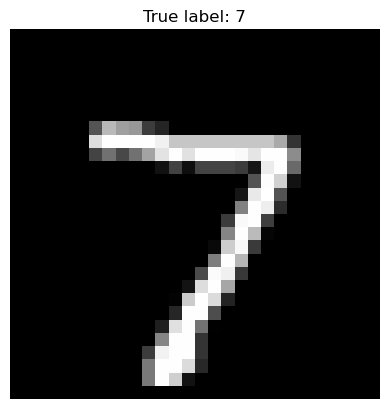

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/step
Predicted class: 7
Class probabilities: [[0. 0. 0. 0. 0. 0. 0. 1. 0. 0.]]


In [7]:
idx = 0
plt.imshow(test_images[idx].reshape(28, 28), cmap='gray')
plt.title(f'True label: {test_labels[idx]}')
plt.axis('off')
plt.show()
pred = model.predict(test_images[idx:idx+1])
print('Predicted class:', pred.argmax())
print('Class probabilities:', pred.round(3))